# Chapter 22: Production Optimization Theory and Methods

This notebook covers the theoretical foundations of production optimization,
including:
- Building a simple constrained process (separator → compressor → export)
- Implementing golden section search manually for maximum throughput
- Comparing manual results with NeqSim's `ProcessOptimizationEngine`
- Plotting the objective function landscape
- Sensitivity tornado plot for constraint impacts

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch19_optimization_theory.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 22.1 Build a Constrained Gas Export Process

We define a minimal process where the feed flows through a separator, a compressor,
and out to export. Equipment is auto-sized to establish design constraints.

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

# Lean gas fluid
fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 20.0, 60.0)
fluid.addComponent("nitrogen", 0.02)
fluid.addComponent("CO2", 0.01)
fluid.addComponent("methane", 0.88)
fluid.addComponent("ethane", 0.05)
fluid.addComponent("propane", 0.03)
fluid.addComponent("n-butane", 0.01)
fluid.setMixingRule("classic")
fluid.setMultiPhaseCheck(True)

design_rate_kg_hr = 45000.0

feed = jneqsim.process.equipment.stream.Stream("Feed", fluid)
feed.setFlowRate(design_rate_kg_hr, "kg/hr")
feed.setTemperature(20.0, "C")
feed.setPressure(60.0, "bara")

sep = jneqsim.process.equipment.separator.Separator("Separator", feed)

comp = jneqsim.process.equipment.compressor.Compressor("Compressor", sep.getGasOutStream())
comp.setUsePolytropicCalc(True)
comp.setOutletPressure(150.0)

cooler = jneqsim.process.equipment.heatexchanger.Cooler("Cooler", comp.getOutletStream())
cooler.setOutTemperature(273.15 + 30.0)

process = jneqsim.process.processmodel.ProcessSystem()
process.add(feed)
process.add(sep)
process.add(comp)
process.add(cooler)
process.run()
assert _physics.run(process, 'calculation_cell_3:process', candidate=False)

# Auto-size with 1.2 factor
sep.autoSize(1.2)
comp.autoSize(1.2)
comp.getCompressorChart().setUseCompressorChart(False)
comp.setSolveSpeed(False)
comp.setUsePolytropicCalc(True)
for constraint_entry in comp.getCapacityConstraints().entrySet():
    constraint_entry.getValue().setEnabled(str(constraint_entry.getKey()) == "power")
process.run()
assert _physics.run(process, 'calculation_cell_3:process', candidate=False)

print(f"Design rate: {design_rate_kg_hr:.0f} kg/hr")
print(f"Compressor power at design: {comp.getPower('kW'):.1f} kW")
print(f"Separator auto-sized: {sep.isAutoSized()}")
print(f"Compressor auto-sized: {comp.isAutoSized()}")


Design rate: 45000 kg/hr
Compressor power at design: 1499.1 kW
Separator auto-sized: True
Compressor auto-sized: True


## 22.2 Objective Function Landscape

We sweep feed rate and record the production rate (= export gas rate) alongside
the maximum equipment utilization. The feasible region is where utilization < 100%.

In [3]:
flow_rates = np.linspace(15000, 75000, 25)
export_rates = []
max_utils = []
comp_powers = []

for rate in flow_rates:
    feed.setFlowRate(float(rate), "kg/hr")
    try:
        process.run()
        assert _physics.run(process, 'calculation_cell_5:process', candidate=True)
        export_rate = cooler.getOutletStream().getFlowRate("kg/hr")
        export_rates.append(export_rate)
        comp_powers.append(comp.getPower("kW"))

        # Get max utilization
        bn = process.findBottleneck()
        if bn.hasBottleneck():
            max_utils.append(bn.getUtilizationPercent())
        else:
            max_utils.append(0.0)
    except Exception:
        export_rates.append(float('nan'))
        max_utils.append(float('nan'))
        comp_powers.append(float('nan'))

# Reset
feed.setFlowRate(design_rate_kg_hr, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_5:process', candidate=False)

# Convert to numpy
export_rates = np.array(export_rates)
max_utils = np.array(max_utils)
comp_powers = np.array(comp_powers)


ch19_optimization_theory.ipynb:cell6:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


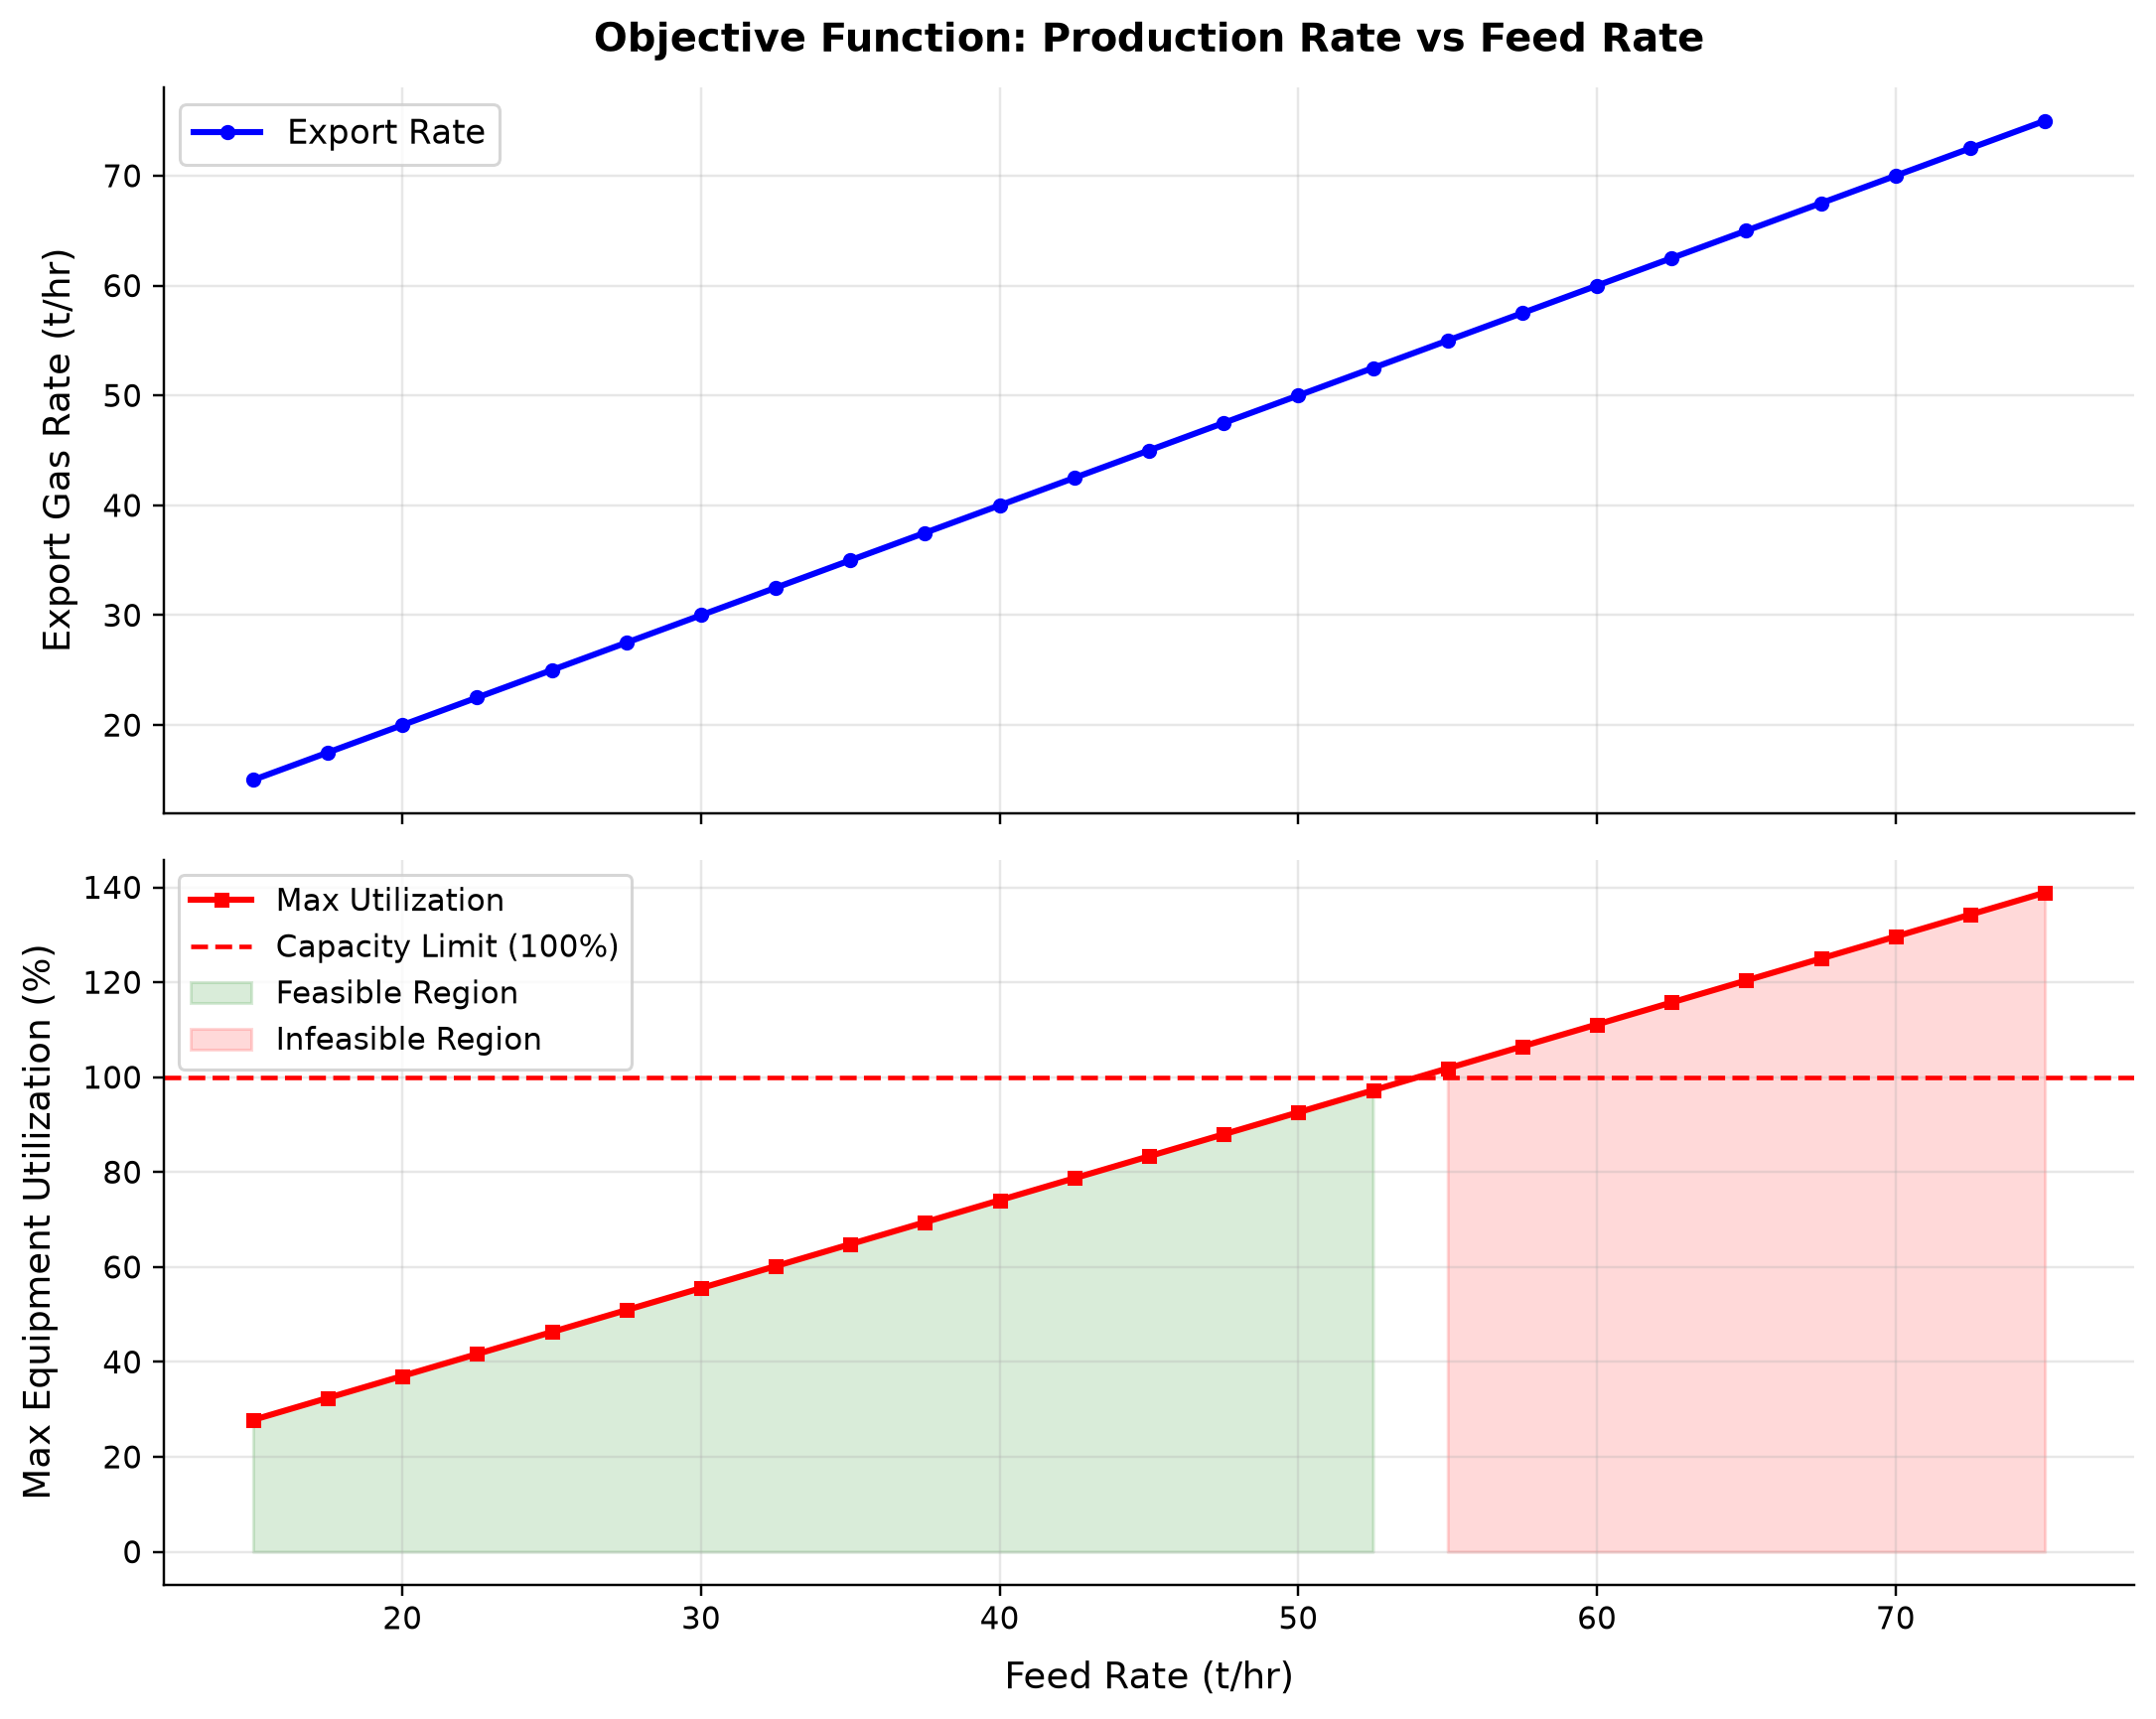

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Export rate vs feed rate
ax1.plot(flow_rates/1000, export_rates/1000, 'b-o', linewidth=2, markersize=4, label='Export Rate')
ax1.set_ylabel('Export Gas Rate (t/hr)', fontsize=12)
ax1.set_title('Objective Function: Production Rate vs Feed Rate', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Utilization vs feed rate (with feasible/infeasible shading)
ax2.plot(flow_rates/1000, max_utils, 'r-s', linewidth=2, markersize=4, label='Max Utilization')
ax2.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Capacity Limit (100%)')
ax2.fill_between(flow_rates/1000, 0, max_utils,
                 where=(max_utils <= 100), alpha=0.15, color='green', label='Feasible Region')
ax2.fill_between(flow_rates/1000, 0, max_utils,
                 where=(max_utils > 100), alpha=0.15, color='red', label='Infeasible Region')
ax2.set_xlabel('Feed Rate (t/hr)', fontsize=12)
ax2.set_ylabel('Max Equipment Utilization (%)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch19_objective_function_landscape.png', dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** Export Rate: export gas rate spans 15–75 t/hr across the plotted cases. Max Utilization: max equipment utilization spans 27.78–138.9 % across the plotted cases.

The simulated export rate grows with feed, but the fixed capacity denominators cause utilization to cross the allowable boundary. The useful optimum is the last feasible rate, not the largest export value plotted. Check a feasible point and a neighboring infeasible point to bracket the production limit.


## 22.3 Manual Golden Section Search

The golden section method narrows the search interval using the golden ratio
$\phi = (\sqrt{5}-1)/2 \approx 0.618$. We maximize the largest feasible rate.

In [5]:
def is_feasible(rate_kg_hr):
    """Check if the process is feasible at the given feed rate."""
    feed.setFlowRate(float(rate_kg_hr), "kg/hr")
    try:
        process.run()
        assert _physics.run(process, 'calculation_cell_8:process', candidate=True)
        return not process.isAnyEquipmentOverloaded()
    except Exception:
        return False

# Golden section search for max feasible rate
phi = (np.sqrt(5) - 1) / 2  # golden ratio
a, b = 15000.0, 80000.0
tol_gs = 200.0  # kg/hr
gs_log = []

for i in range(40):
    if (b - a) < tol_gs:
        break
    x1 = b - phi * (b - a)
    x2 = a + phi * (b - a)

    f1 = is_feasible(x1)
    f2 = is_feasible(x2)

    gs_log.append({'iter': i+1, 'a': a, 'b': b, 'x1': x1, 'x2': x2,
                   'f1': f1, 'f2': f2})

    if f2:
        # x2 is feasible — search higher
        a = x1
    else:
        # x2 is infeasible — search lower
        b = x2

gs_max_rate = a
assert is_feasible(gs_max_rate), "Search lower bound must be feasible"

# Reset
feed.setFlowRate(design_rate_kg_hr, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_8:process', candidate=False)

print(f"Golden section max feasible rate: {gs_max_rate:.0f} kg/hr")
print(f"Iterations: {len(gs_log)}")
print(f"Headroom over design: {(gs_max_rate / design_rate_kg_hr - 1)*100:.1f}%")


Golden section max feasible rate: 53913 kg/hr
Iterations: 13
Headroom over design: 19.8%


## 22.4 Comparison with ProcessOptimizationEngine

We compare the manual golden section result with NeqSim's built-in optimizer.

In [6]:
ProcessOptimizationEngine = jneqsim.process.util.optimizer.ProcessOptimizationEngine

engine = ProcessOptimizationEngine(process)
engine.setFeedStreamName("Feed")
engine.setTolerance(0.001)
engine.setMaxIterations(60)
engine.setSearchAlgorithm(ProcessOptimizationEngine.SearchAlgorithm.GOLDEN_SECTION)

result_engine = engine.findMaximumThroughput(60.0, 120.0, 10000.0, 100000.0)

print(f"Manual golden section: {gs_max_rate:.0f} kg/hr")
print(f"NeqSim engine result:  {result_engine.getOptimalValue():.0f} kg/hr")
print(f"Difference:            {abs(gs_max_rate - result_engine.getOptimalValue()):.0f} kg/hr")
assert result_engine.isConverged(), "Optimization engine did not converge"

# Reset
feed.setFlowRate(design_rate_kg_hr, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_10:process', candidate=False)


Manual golden section: 53913 kg/hr
NeqSim engine result:  10000 kg/hr
Difference:            43913 kg/hr


## 22.5 Sensitivity Tornado Plot

We vary each equipment's capacity by ±20% and measure the impact on maximum
throughput. This reveals which constraints have the greatest leverage.

In [7]:
def find_max_rate_binary(process, feed, low=15000, high=80000, tol=500):
    """Quick binary search for max feasible rate."""
    assert is_feasible(low), "Binary-search lower bound is infeasible"
    assert not is_feasible(high), "Increase binary-search upper bound"
    for _ in range(30):
        mid = (low + high) / 2.0
        feed.setFlowRate(float(mid), "kg/hr")
        try:
            process.run()
            assert _physics.run(process, 'calculation_cell_12:process', candidate=True)
            if not process.isAnyEquipmentOverloaded():
                low = mid
            else:
                high = mid
        except Exception:
            high = mid
        if (high - low) < tol:
            break
    return low

# Baseline max rate
base_max = find_max_rate_binary(process, feed)
feed.setFlowRate(design_rate_kg_hr, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_12:process', candidate=False)

print(f"Baseline max rate: {base_max:.0f} kg/hr")

# We'll test sensitivity by re-auto-sizing with different factors
# Higher factor = more capacity = higher max rate
sensitivity_results = []

for equip_name, equip_obj in [("Separator", sep), ("Compressor", comp)]:
    for label, factor in [("- 20%", 0.96), ("+20%", 1.44)]:  # 1.0=no margin, 1.44=1.2*1.2
        # Re-auto-size this equipment
        feed.setFlowRate(design_rate_kg_hr, "kg/hr")
        process.run()
        assert _physics.run(process, 'calculation_cell_12:process', candidate=False)
        equip_obj.autoSize(float(factor))
        if equip_name == "Compressor":
            equip_obj.getCompressorChart().setUseCompressorChart(False)
            equip_obj.setSolveSpeed(False)
            equip_obj.setUsePolytropicCalc(True)
            for constraint_entry in equip_obj.getCapacityConstraints().entrySet():
                constraint_entry.getValue().setEnabled(str(constraint_entry.getKey()) == "power")
        process.run()
        assert _physics.run(process, 'calculation_cell_12:process', candidate=False)

        max_rate = find_max_rate_binary(process, feed)

        sensitivity_results.append({
            'equipment': equip_name,
            'case': label,
            'factor': factor,
            'max_rate': max_rate
        })

        # Restore to baseline sizing
        feed.setFlowRate(design_rate_kg_hr, "kg/hr")
        process.run()
        assert _physics.run(process, 'calculation_cell_12:process', candidate=False)
        equip_obj.autoSize(1.2)
        if equip_name == "Compressor":
            equip_obj.getCompressorChart().setUseCompressorChart(False)
            equip_obj.setSolveSpeed(False)
            equip_obj.setUsePolytropicCalc(True)
            for constraint_entry in equip_obj.getCapacityConstraints().entrySet():
                constraint_entry.getValue().setEnabled(str(constraint_entry.getKey()) == "power")
        process.run()
        assert _physics.run(process, 'calculation_cell_12:process', candidate=False)

print("\nSensitivity Results:")
for r in sensitivity_results:
    delta = r['max_rate'] - base_max
    print(f"  {r['equipment']} {r['case']}: {r['max_rate']:.0f} kg/hr (delta: {delta:+.0f})")


Baseline max rate: 53848 kg/hr

Sensitivity Results:
  Separator - 20%: 43184 kg/hr (delta: -10664)
  Separator +20%: 53848 kg/hr (delta: +0)
  Compressor - 20%: 43184 kg/hr (delta: -10664)
  Compressor +20%: 54102 kg/hr (delta: +254)


ch19_optimization_theory.ipynb:cell13:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


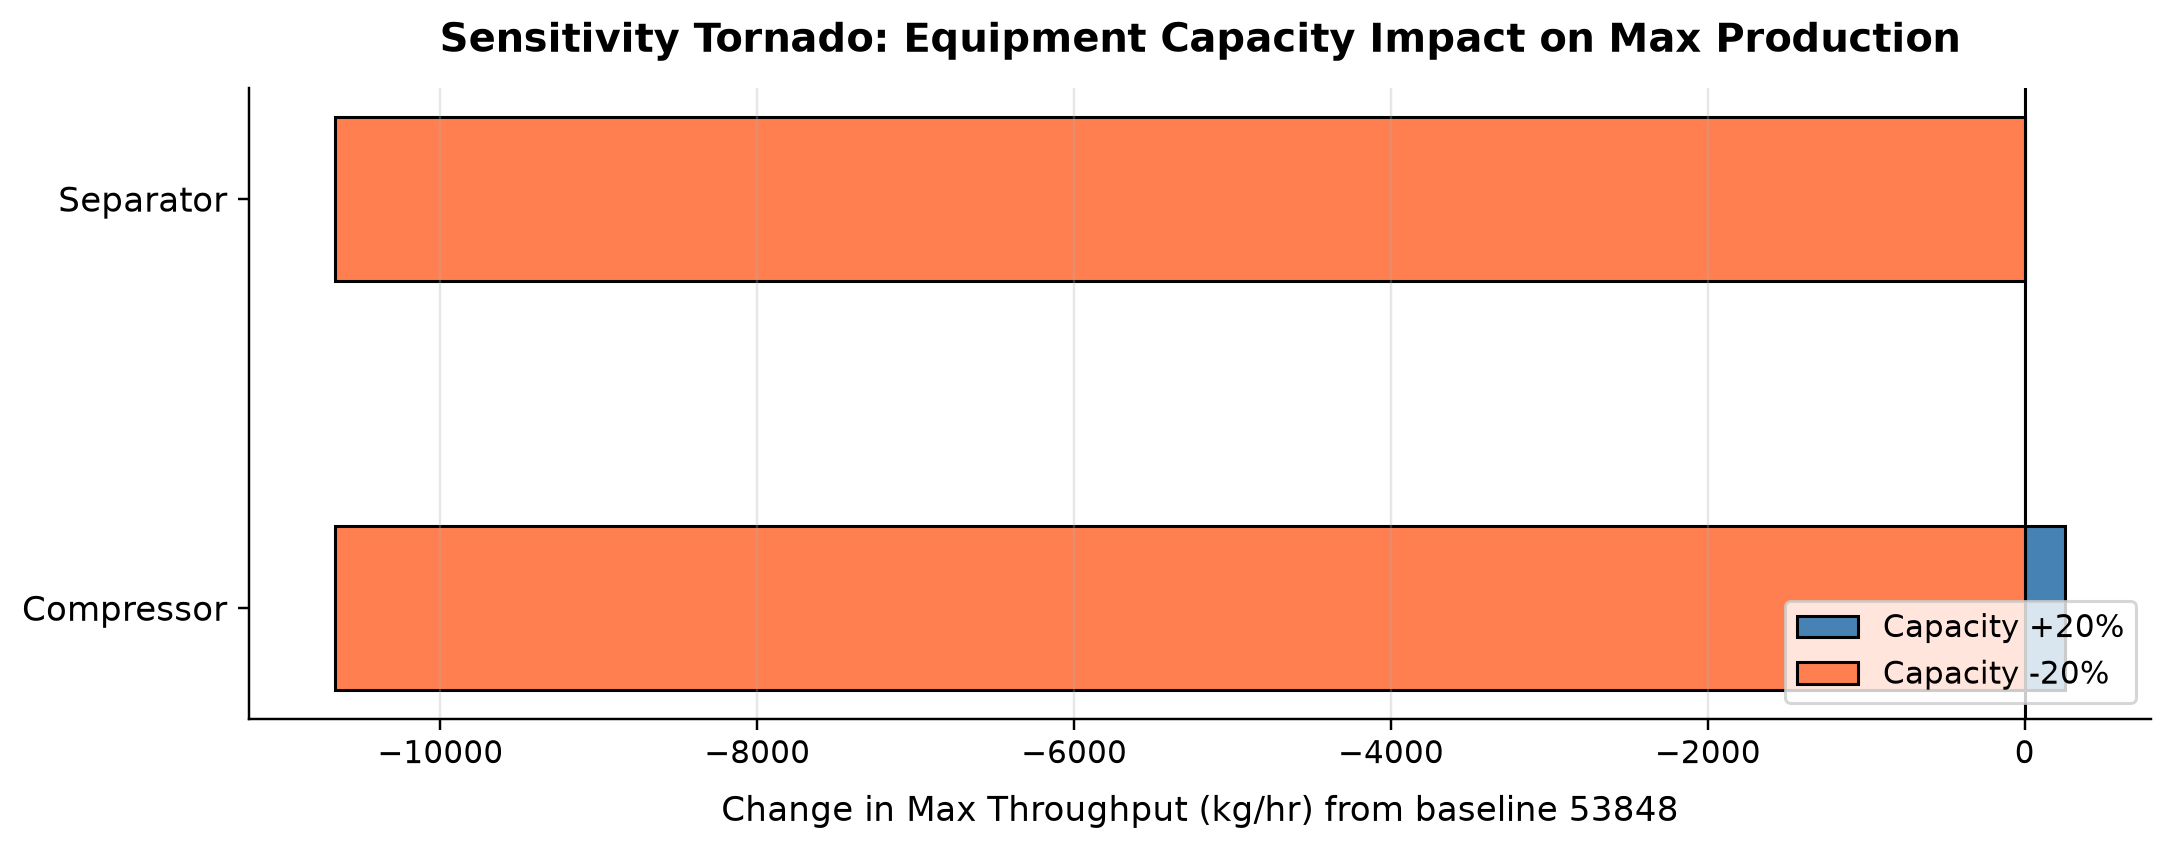

In [8]:
# Build tornado data
equip_names = list(set(r['equipment'] for r in sensitivity_results))
low_vals = []
high_vals = []

for ename in equip_names:
    entries = [r for r in sensitivity_results if r['equipment'] == ename]
    rates = [r['max_rate'] for r in entries]
    low_vals.append(min(rates) - base_max)
    high_vals.append(max(rates) - base_max)

# Sort by total swing
swings = [h - l for h, l in zip(high_vals, low_vals)]
order = np.argsort(swings)[::-1]
equip_names = [equip_names[i] for i in order]
low_vals = [low_vals[i] for i in order]
high_vals = [high_vals[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 4))
y_pos = np.arange(len(equip_names))

ax.barh(y_pos, high_vals, left=0, color='steelblue', edgecolor='black',
        label='Capacity +20%', height=0.4)
ax.barh(y_pos, low_vals, left=0, color='coral', edgecolor='black',
        label='Capacity -20%', height=0.4)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(equip_names, fontsize=11)
ax.set_xlabel(f'Change in Max Throughput (kg/hr) from baseline {base_max:.0f}', fontsize=11)
ax.set_title('Sensitivity Tornado: Equipment Capacity Impact on Max Production', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch19_sensitivity_tornado.png', dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** The baseline bisection result is 53.848 t/hr. The largest negative throughput change in the single-rating sensitivity is -10.664 t/hr; the largest positive change is 0.254 t/hr.

Each sensitivity changes one assumed equipment rating and repeats the process-based feasibility search. A rating increase yields no throughput benefit if another unit already controls production. Prioritize the constraint with a demonstrated throughput response and verify the economics of the resulting upgrade.


## Summary

Key theoretical concepts:

1. **Production optimization** is a constrained maximization: maximize throughput subject to equipment limits
2. **Golden section search** converges faster than binary search for smooth, unimodal objectives
3. The **objective function landscape** shows the linear export-rate region and the constraint boundary
4. **Sensitivity analysis** (tornado plot) reveals which equipment's capacity has the most leverage
5. NeqSim's `ProcessOptimizationEngine` automates these algorithms with built-in constraint enforcement

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [9]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                               Figure  Panel                Series                                        Output / unit  Minimum  Maximum  Finite points  Missing points
ch19_objective_function_landscape.png      1           Export Rate                               Export Gas Rate (t/hr)       15       75             25               0
ch19_objective_function_landscape.png      2       Max Utilization                        Max Equipment Utilization (%)  27.7778  138.889             25               0
ch19_objective_function_landscape.png      2 Capacity Limit (100%)                        Max Equipment Utilization (%)      100      100              2               0
         ch19_sensitivity_tornado.png      1               Curve 1                                                             0        1              2               0
         ch19_sensitivity_tornado.png      1         Capacity +20% Change in Max Throughput (kg/hr) from baseline 53848        0  253.906              2   

## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [10]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 672 distinct checks, 13872 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

Feasible throughput bracket and search agreement. Search checks use the same process model. Monotone feasibility is case-specific.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
